In [ ]:
# --- parameters (patch_notebook_params.py) ---
MAX_EPOCHS = 2000
N_SAMPLES = 10           # run_metrics.py forces 50 for generative methods
RESET_TRAINING = False
CUDA_VISIBLE_DEVICES = "0"
METRICS_CSV = "results/metrics.csv"


In [ ]:
# --- epoch heartbeat (patch_notebook_params.py) ---
import pytorch_lightning as _pl

class EpochHeartbeat(_pl.Callback):
    """Prints one clear progress line every `every_n_epochs` epochs, so
    sbatch logs show training progress without the noise of a per-batch
    tqdm progress bar (which doesn't render well once redirected to a
    plain log file).    """

    def __init__(self, every_n_epochs: int = 20):
        self.every_n_epochs = every_n_epochs

    def on_train_epoch_end(self, trainer, pl_module):
        epoch = trainer.current_epoch + 1
        if epoch % self.every_n_epochs != 0 and epoch != trainer.max_epochs:
            return
        parts = []
        for k, v in sorted(trainer.callback_metrics.items()):
            try:
                parts.append(f'{k}={float(v):.4f}')
            except (TypeError, ValueError):
                pass
        print(f'[progress] epoch {epoch}/{trainer.max_epochs} | ' + ' | '.join(parts), flush=True)


## Consistency Model — Sea Ice Concentration (SIC)

In [15]:
!nvidia-smi

Wed Jun 24 19:29:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.42.02              Driver Version: 555.42.02      CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     Off |   00000000:4A:00.0 Off |                    0 |
|  0%   55C    P0            134W /  300W |   14009MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [16]:
import os; os.environ["CUDA_VISIBLE_DEVICES"] = CUDA_VISIBLE_DEVICES

env: CUDA_VISIBLE_DEVICES=3


In [17]:
import json
import math
import os
import zipfile
import glob
import importlib
from dataclasses import asdict, dataclass
from typing import Any, Callable, List, Optional, Tuple, Union

import numpy as np
import xarray as xr
import pandas as pd
import torch
from einops import rearrange
from einops.layers.torch import Rearrange
import pytorch_lightning as pl
from pytorch_lightning import LightningModule, Trainer, seed_everything
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from matplotlib import pyplot as plt
from torch import Tensor, nn
from torch.nn import functional as F
from torchinfo import summary

import sys
sys.path.append('../..')     # -> consistency/  (consistency_models, spectral_utils)
sys.path.append('../../..')  # -> 4dvarnet-starter-devs/

import consistency_models.utils
import consistency_models.consistency_models_CM
importlib.reload(consistency_models.utils)
importlib.reload(consistency_models.consistency_models_CM)

from consistency_models.consistency_models_CM import (
    ConsistencySamplingAndEditingFewSteps_TimeEmbedding,
    ConsistencyTrainingFewSteps_TimeEmbedding,
    ema_decay_rate_schedule,
)
from consistency_models.utils import update_ema_model_, pseudo_huber_loss

try:
    from properscoring import crps_ensemble
    HAS_PROPERSCORING = True
except ImportError:
    HAS_PROPERSCORING = False
    print("properscoring not installed -- CRPS disabled.")

## ⚠️ ACTION REQUIRED — automatically generated notebook

This notebook (`4dvarnet_lstm` / `SIC`) was assembled by `sbatch_submission/generate_missing_notebooks.py`, combining the data loading of xp `SIC` with the method code of the GP reference notebook. Points to validate before a production run:

- **LOG_DIR** automatically set to `logs_4dvarnet_lstm_sic` — check it doesn't collide with an existing run.
- **sigma_max / SIGMA_NOISE**: value carried over as-is from the GP source notebook — needs to be re-tuned to this variable's physical scale (cf. SIC ≈ 1.0, SSH_GF ≈ 10, GP to verify) before any production run.
- **cond_channels**: `UNetConfig(channels=C)` was automatically rewritten to `UNetConfig(channels=C, cond_channels=2*C)` (factor inferred from the existing SIC/CM notebook). Verify this factor is correct for the config class used by **4dvarnet_lstm** (may differ from CM's) and that the forward pass actually concatenates the right conditioning fields.
- **Masked loss (NaN)**: this xp has NaN gaps in the target. The matching FM notebook (`Notebook_flowmatching_model_FM_sic.ipynb`, class `LitFlowMatchingSIC.training_step`) already implements masking via `masked_average` — **this generated notebook did NOT reproduce it automatically** for this method's Lightning class. Must be done before any real training run, otherwise the model will train on NaN noise.

## DataModule -- SIC (ASIP / OSISAF)

C=9, H=240, W=240
Train: 300, Val: 50, Test: 43
asip: (9, 240, 240)  input: (9, 240, 240)  osisaf: (9, 240, 240)
asip range: [0.000, 1.000]
asip std: 0.4139
NaN fraction in asip: 22.2%


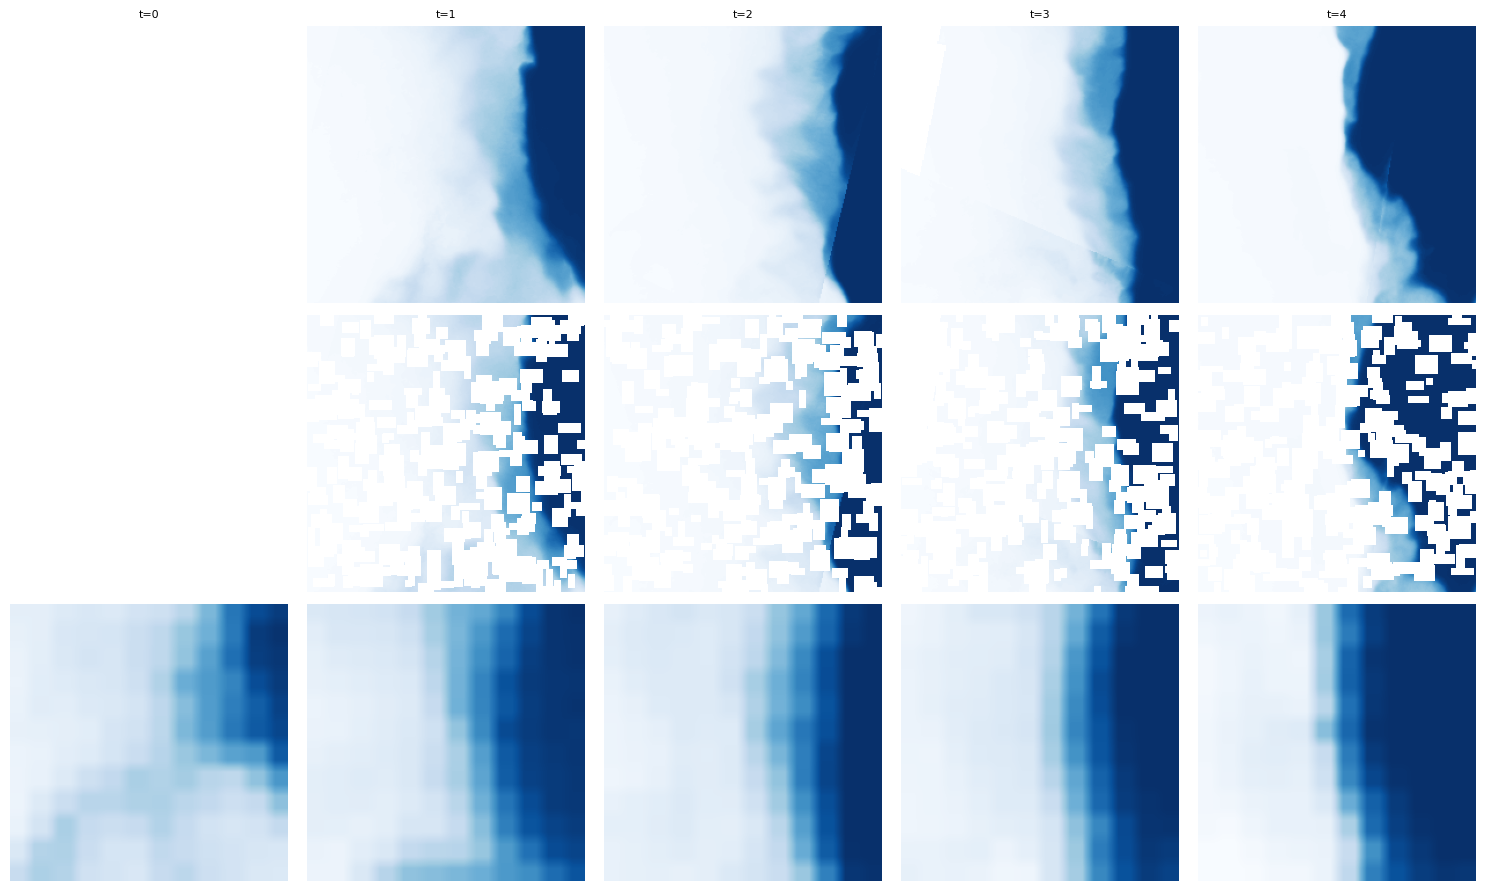

In [18]:
sys.path.insert(0, '/Odyssey/private/m19beauc/4dvarnet-starter')
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'

import functools as ft
from contrib.ASIP_OSISAF.data_simple import BaseDataModule, TrainingItem_4da

T_CROP = 9

class CroppedDataModule(BaseDataModule):
    def __init__(self, *args, t_crop=9, **kwargs):
        super().__init__(*args, **kwargs)
        self.t_crop = t_crop

    def build_batch(self):
        # ASIP/input/osisaf are already in [0, 1] in the NetCDF file — no rescaling needed
        return ft.partial(ft.reduce, lambda i, f: f(i), [
            TrainingItem_4da._make,
        ])

    def setup(self, stage='test'):
        super().setup(stage)
        for ds in [self.train_ds, self.val_ds, self.test_ds]:
            ds.db = ds.db.isel(time=slice(-self.t_crop, None))

datamodule = CroppedDataModule(
    asip_paths="data/asip_database_daw15_sparse.nc",
    split_train=slice(0, 300),
    split_val=slice(300, 350),
    split_test=slice(350, 393),
    da=True,
    norm_stats=[0, 1],
    norm_stats_covs=[
        {'t2m': 270.08, 'istl1': 267.68, 'siconc': 0, 'sst': 276.97, 'skt': 270.50},
        {'t2m': 14.67,  'istl1': 7.80,  'siconc': 1, 'sst': 6.82,   'skt': 15.21},
    ],
    t_crop=T_CROP,
)
datamodule.setup()

sample = datamodule.train_ds[0]
C = sample.asip.shape[0]
H, W = sample.asip.shape[1], sample.asip.shape[2]
print(f"C={C}, H={H}, W={W}")
print(f"Train: {len(datamodule.train_ds)}, Val: {len(datamodule.val_ds)}, Test: {len(datamodule.test_ds)}")
print(f"asip: {sample.asip.shape}  input: {sample.input.shape}  osisaf: {sample.osisaf.shape}")
print(f"asip range: [{np.nanmin(sample.asip):.3f}, {np.nanmax(sample.asip):.3f}]")
print(f"asip std: {np.nanstd(sample.asip):.4f}")
print(f"NaN fraction in asip: {np.isnan(sample.asip).mean()*100:.1f}%")

fig, axes = plt.subplots(3, min(C, 5), figsize=(3 * min(C, 5), 9))
for t_idx in range(min(C, 5)):
    axes[0, t_idx].imshow(sample.asip[t_idx], vmin=0, vmax=1, cmap='Blues_r')
    axes[0, t_idx].set_title(f't={t_idx}', fontsize=8); axes[0, t_idx].axis('off')
    axes[1, t_idx].imshow(sample.input[t_idx], vmin=0, vmax=1, cmap='Blues_r')
    axes[1, t_idx].axis('off')
    axes[2, t_idx].imshow(sample.osisaf[t_idx], vmin=0, vmax=1, cmap='Blues_r')
    axes[2, t_idx].axis('off')
axes[0, 0].set_ylabel('ASIP (target)', fontsize=10)
axes[1, 0].set_ylabel('Input (gappy)', fontsize=10)
axes[2, 0].set_ylabel('OSISAF (cond.)', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# --- overrides enforced by methods.yaml (generate_missing_notebooks.py) ---
SOLVER_TYPE = 'lstm'

### UNet Modules (dataset-agnostic — copied from reference notebook)

In [7]:
def GroupNorm(channels: int) -> nn.GroupNorm:
    return nn.GroupNorm(num_groups=min(32, channels // 4), num_channels=channels)


class SelfAttention(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 n_heads: int = 8, dropout: float = 0.3) -> None:
        super().__init__()
        self.dropout = dropout
        self.qkv_projection = nn.Sequential(
            GroupNorm(in_channels),
            nn.Conv2d(in_channels, 3 * in_channels, kernel_size=1, bias=False),
            Rearrange("b (i h d) x y -> i b h (x y) d", i=3, h=n_heads),
        )
        self.output_projection = nn.Sequential(
            Rearrange("b h l d -> b l (h d)"),
            nn.Linear(in_channels, out_channels, bias=False),
            Rearrange("b l d -> b d l"),
            GroupNorm(out_channels),
            nn.Dropout1d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor) -> Tensor:
        q, k, v = self.qkv_projection(x).unbind(dim=0)
        output = F.scaled_dot_product_attention(
            q, k, v, dropout_p=self.dropout if self.training else 0.0, is_causal=False
        )
        output = self.output_projection(output)
        output = rearrange(output, "b c (x y) -> b c x y", x=x.shape[-2], y=x.shape[-1])
        return output + self.residual_projection(x)


class UNetBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 noise_level_channels: int, dropout: float = 0.3) -> None:
        super().__init__()
        self.input_projection = nn.Sequential(
            GroupNorm(in_channels), nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.noise_level_projection = nn.Sequential(
            nn.SiLU(),
            nn.Conv2d(noise_level_channels, out_channels, kernel_size=1),
        )
        self.output_projection = nn.Sequential(
            GroupNorm(out_channels), nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor, cond: Tensor) -> Tensor:
        h = self.input_projection(x)
        h = h + self.noise_level_projection(cond)
        return self.output_projection(h) + self.residual_projection(x)


class UNetBlockWithSelfAttention(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 noise_level_channels: int, n_heads: int = 8, dropout: float = 0.3) -> None:
        super().__init__()
        self.unet_block = UNetBlock(in_channels, out_channels, noise_level_channels, dropout)
        self.self_attention = SelfAttention(out_channels, out_channels, n_heads, dropout)

    def forward(self, x: Tensor, cond: Tensor) -> Tensor:
        return self.self_attention(self.unet_block(x, cond))


class Downsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.projection = nn.Sequential(
            Rearrange("b c (h ph) (w pw) -> b (c ph pw) h w", ph=2, pw=2),
            nn.Conv2d(4 * channels, channels, kernel_size=1),
        )
    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


class Upsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.projection = nn.Sequential(
            nn.Upsample(scale_factor=2.0, mode="nearest"),
            nn.Conv2d(channels, channels, kernel_size=3, padding="same"),
        )
    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


### Sinusoidal Time Embedding

Solver step $t_k = k/(N-1) \in [0,1]$ → conditioning vector `(B, D, 1, 1)` injected into each UNetBlock.


In [8]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim: int = 128, out_dim: Optional[int] = None) -> None:
        super().__init__()
        out_dim = out_dim or dim
        half = dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, dtype=torch.float32) / (half - 1)
        )
        self.register_buffer("freqs", freqs)
        self.mlp = nn.Sequential(
            nn.Linear(dim, 4 * dim),
            nn.SiLU(),
            nn.Linear(4 * dim, out_dim),
        )

    def forward(self, t: Tensor) -> Tensor:
        if t.dim() == 0:
            t = t.unsqueeze(0)
        t = t.float()
        angles = t[:, None] * self.freqs[None, :]
        emb = torch.cat([angles.sin(), angles.cos()], dim=-1)
        emb = emb.to(dtype=next(self.mlp.parameters()).dtype)
        emb = self.mlp(emb)
        return emb[:, :, None, None]


### UNet Gradient Model

`GradSolverUNetConfig.channels` is set to the **number of time steps per patch** (= `window_size` = 15).


In [9]:
@dataclass
class GradSolverUNetConfig:
    channels: int = 5                                     # C = window_size (time steps per patch)
    time_emb_dim: int = 128
    n_heads: int = 8
    top_blocks_channels: Tuple[int, ...] = (56, 56)
    top_blocks_n_blocks_per_resolution: Tuple[int, ...] = (2, 2)
    top_blocks_has_resampling: Tuple[bool, ...] = (True, True)
    top_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)
    mid_blocks_channels: Tuple[int, ...] = (128, 256)
    mid_blocks_n_blocks_per_resolution: Tuple[int, ...] = (4, 4)
    mid_blocks_has_resampling: Tuple[bool, ...] = (True, False)
    mid_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)


def _pad_to_multiple(x: Tensor, multiple: int = 8) -> Tuple[Tensor, Tuple[int, int, int, int]]:
    """Pad H and W to the nearest multiple of `multiple` using reflection padding."""
    _, _, H, W = x.shape
    pad_h = (multiple - H % multiple) % multiple
    pad_w = (multiple - W % multiple) % multiple
    # F.pad: (left, right, top, bottom)
    padding = (0, pad_w, 0, pad_h)
    return F.pad(x, padding, mode="reflect"), padding


def _unpad(x: Tensor, padding: Tuple[int, int, int, int]) -> Tensor:
    """Remove the padding added by _pad_to_multiple."""
    _, pad_w, _, pad_h = padding
    H, W = x.shape[-2], x.shape[-1]
    return x[..., :H - pad_h if pad_h else H, :W - pad_w if pad_w else W]


class GradSolverUNet(nn.Module):
    def __init__(self, config: GradSolverUNetConfig) -> None:
        super().__init__()
        self.config = config
        C   = config.channels
        D   = config.top_blocks_channels[0]
        EMB = config.time_emb_dim

        self.time_embedding    = SinusoidalTimeEmbedding(dim=EMB, out_dim=EMB)
        self.input_projection  = nn.Conv2d(2 * C, D, kernel_size=3, padding="same")

        self.top_encoder_blocks = self._make_encoder_blocks(
            config.top_blocks_channels + config.mid_blocks_channels[:1],
            config.top_blocks_n_blocks_per_resolution,
            config.top_blocks_has_resampling,
            config.top_blocks_dropout, self._make_top_block)
        self.mid_encoder_blocks = self._make_encoder_blocks(
            config.mid_blocks_channels + config.mid_blocks_channels[-1:],
            config.mid_blocks_n_blocks_per_resolution,
            config.mid_blocks_has_resampling,
            config.mid_blocks_dropout, self._make_mid_block)
        self.mid_decoder_blocks = self._make_decoder_blocks(
            config.mid_blocks_channels + config.mid_blocks_channels[-1:],
            config.mid_blocks_n_blocks_per_resolution,
            config.mid_blocks_has_resampling,
            config.mid_blocks_dropout, self._make_mid_block)
        self.top_decoder_blocks = self._make_decoder_blocks(
            config.top_blocks_channels + config.mid_blocks_channels[:1],
            config.top_blocks_n_blocks_per_resolution,
            config.top_blocks_has_resampling,
            config.top_blocks_dropout, self._make_top_block)

        self.output_projection = nn.Conv2d(D, C, kernel_size=3, padding="same")

    def forward(self, x: Tensor, grad_j: Tensor, t: Tensor) -> Tensor:
        grad_norm = (grad_j ** 2).mean().sqrt().clamp(min=1e-8)
        grad_j_n  = grad_j / grad_norm

        # Pad both inputs to a multiple of 8 so Downsample never gets odd dims
        inp = torch.cat([x, grad_j_n], dim=1)
        inp, padding = _pad_to_multiple(inp, multiple=8)

        h    = self.input_projection(inp)
        cond = self.time_embedding(t)

        top_skips = []
        for block in self.top_encoder_blocks:
            if isinstance(block, UNetBlock):
                h = block(h, cond); top_skips.append(h)
            else:
                h = block(h)

        mid_skips = []
        for block in self.mid_encoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = block(h, cond); mid_skips.append(h)
            else:
                h = block(h)

        for block in self.mid_decoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = torch.cat((h, mid_skips.pop()), dim=1); h = block(h, cond)
            else:
                h = block(h)

        for block in self.top_decoder_blocks:
            if isinstance(block, UNetBlock):
                h = torch.cat((h, top_skips.pop()), dim=1); h = block(h, cond)
            else:
                h = block(h)

        out = self.output_projection(h)
        return _unpad(out, padding)   # restore original H×W

    def _make_encoder_blocks(self, channels, n_blocks, has_resampling, dropout, block_fn):
        blocks = nn.ModuleList()
        for idx, (ic, oc) in enumerate(zip(channels[:-1], channels[1:])):
            for _ in range(n_blocks[idx]):
                blocks.append(block_fn(ic, oc, dropout[idx])); ic = oc
            if has_resampling[idx]:
                blocks.append(Downsample(oc))
        return blocks

    def _make_decoder_blocks(self, channels, n_blocks, has_resampling, dropout, block_fn):
        blocks = nn.ModuleList()
        for idx, (oc, ic) in enumerate(list(zip(channels[:-1], channels[1:]))[::-1]):
            if has_resampling[::-1][idx]:
                blocks.append(Upsample(ic))
            inner = []
            for _ in range(n_blocks[::-1][idx]):
                inner.append(block_fn(ic * 2, oc, dropout[::-1][idx])); oc = ic
            blocks.extend(inner[::-1])
        return blocks

    def _make_top_block(self, ic, oc, dropout):
        return UNetBlock(ic, oc, self.config.time_emb_dim, dropout)

    def _make_mid_block(self, ic, oc, dropout):
        return UNetBlockWithSelfAttention(ic, oc, self.config.time_emb_dim, self.config.n_heads, dropout)

    def save_pretrained(self, pretrained_path: str) -> None:
        os.makedirs(pretrained_path, exist_ok=True)
        with open(os.path.join(pretrained_path, "config_4dvarnet_unet.json"), mode="w") as f:
            json.dump(asdict(self.config), f)
        torch.save(self.state_dict(), os.path.join(pretrained_path, "model_4dvarnet_unet.pt"))

    @classmethod
    def from_pretrained(cls, pretrained_path: str) -> "GradSolverUNet":
        with open(os.path.join(pretrained_path, "config_4dvarnet_unet.json"), mode="r") as f:
            config_dict = json.load(f)
        model = cls(GradSolverUNetConfig(**config_dict))
        model.load_state_dict(torch.load(
            os.path.join(pretrained_path, "model_4dvarnet_unet.pt"), map_location="cpu"))
        return model


# Sanity check — 100×100 will be padded to 104×104 internally
C = datamodule.window_size
summary(
    GradSolverUNet(GradSolverUNetConfig(channels=C, cond_channels=2*C)),
    input_data=[
        torch.zeros(1, C, 100, 100),
        torch.zeros(1, C, 100, 100),
        torch.tensor([0.5]),
    ],
)


Layer (type:depth-idx)                        Output Shape              Param #
GradSolverUNet                                [1, 5, 100, 100]          --
├─Conv2d: 1-1                                 [1, 56, 104, 104]         5,096
├─SinusoidalTimeEmbedding: 1-2                [1, 128, 1, 1]            --
│    └─Sequential: 2-1                        [1, 128]                  --
│    │    └─Linear: 3-1                       [1, 512]                  66,048
│    │    └─SiLU: 3-2                         [1, 512]                  --
│    │    └─Linear: 3-3                       [1, 128]                  65,664
├─ModuleList: 1-3                             --                        --
│    └─UNetBlock: 2-2                         [1, 56, 104, 104]         --
│    │    └─Sequential: 3-4                   [1, 56, 104, 104]         28,392
│    │    └─Sequential: 3-5                   [1, 56, 1, 1]             7,224
│    │    └─Sequential: 3-6                   [1, 56, 104, 104]         28,39

### Observation Operator & Variational Cost

$J(x) = \|m \odot (x - y)\|^2 + \alpha\,\|x - \text{AE}(x)\|^2$

Mask derived from finite values: `mask = y.isfinite()`, `y_filled = y.nan_to_num(0.0)`.


In [10]:
class ObsCost(nn.Module):
    def __init__(self, w: float = 1.0) -> None:
        super().__init__()
        self.w = w

    def forward(self, state: Tensor, y_filled: Tensor, mask: Tensor) -> Tensor:
        return self.w * F.mse_loss(state * mask, y_filled * mask)


class BilinAEPriorCost(nn.Module):
    def __init__(self, dim_in: int, dim_hidden: int,
                 kernel_size: int = 3, downsamp: Optional[int] = None,
                 bilin_quad: bool = True) -> None:
        super().__init__()
        self.bilin_quad = bilin_quad
        self.conv_in     = nn.Conv2d(dim_in, dim_hidden, kernel_size, padding=kernel_size // 2)
        self.conv_hidden = nn.Conv2d(dim_hidden, dim_hidden, kernel_size, padding=kernel_size // 2)
        self.bilin_1     = nn.Conv2d(dim_hidden, dim_hidden, kernel_size, padding=kernel_size // 2)
        self.bilin_21    = nn.Conv2d(dim_hidden, dim_hidden, kernel_size, padding=kernel_size // 2)
        self.bilin_22    = nn.Conv2d(dim_hidden, dim_hidden, kernel_size, padding=kernel_size // 2)
        self.conv_out    = nn.Conv2d(2 * dim_hidden, dim_in, kernel_size, padding=kernel_size // 2)
        self.down = nn.AvgPool2d(downsamp) if downsamp else nn.Identity()
        self.up   = nn.UpsamplingBilinear2d(scale_factor=downsamp) if downsamp else nn.Identity()

    def forward_ae(self, x: Tensor) -> Tensor:
        x = self.down(x)
        x = self.conv_hidden(F.relu(self.conv_in(x)))
        nonlin = self.bilin_21(x) ** 2 if self.bilin_quad else self.bilin_21(x) * self.bilin_22(x)
        x = self.conv_out(torch.cat([self.bilin_1(x), nonlin], dim=1))
        return self.up(x)

    def forward(self, state: Tensor) -> Tensor:
        return F.mse_loss(state, self.forward_ae(state))


def compute_grad_j(state, y_filled, mask, obs_cost, prior_cost, alpha=1.0):
    x = state.requires_grad_(True)
    J = obs_cost(x, y_filled, mask) + alpha * prior_cost(x)
    return torch.autograd.grad(J, x, create_graph=True)[0]


### 4DVarNet Solver

$x_{k+1} = x_k - \text{UNet}(x_k,\; \nabla_x J(x_k),\; t_k)$,  with $x_0 = y_\text{filled}$


In [11]:
class Solver4DVarUNet(nn.Module):
    def __init__(self, grad_model, obs_cost, prior_cost,
                 n_solver: int = 15, alpha_prior: float = 0.2) -> None:
        super().__init__()
        self.grad_model  = grad_model
        self.obs_cost    = obs_cost
        self.prior_cost  = prior_cost
        self.n_solver    = n_solver
        self.alpha_prior = alpha_prior

    def forward(self, y_filled: Tensor, mask: Tensor,
                return_all_iterates: bool = False) -> Union[Tensor, List[Tensor]]:
        B, C, H, W = y_filled.shape
        device, dtype = y_filled.device, y_filled.dtype
        x = y_filled.clone()
        iterates = [x] if return_all_iterates else None

        with torch.set_grad_enabled(True):
            for k in range(self.n_solver):
                t_k = torch.full((B,), k / max(self.n_solver - 1, 1), device=device, dtype=dtype)
                grad_j = compute_grad_j(x, y_filled, mask, self.obs_cost, self.prior_cost, self.alpha_prior)
                dx = self.grad_model(x, grad_j, t_k)
                x  = x - dx
                if not self.training:
                    x = x.detach().requires_grad_(True)
                if return_all_iterates:
                    iterates.append(x)

        return iterates if return_all_iterates else x


### ConvLSTM Gradient Model & Solver (alternative to UNet)

`ConvLstmGradModel` maintains a hidden/cell state across solver iterations — it takes only $\nabla_x J$ as input (no $x$ or $t_k$).

The update rule follows the original 4DVarNet formulation:

$$x_{k+1} = x_k - \left[\frac{1}{k+1}\,\text{LSTM}(\nabla_x J_k) + \eta\,\frac{k+1}{N}\,\nabla_x J_k\right]$$

where $\eta$ is `lr_grad`.


In [12]:
@dataclass
class Lit4DVarUNetConfig:
    lr: float = 1e-4
    betas: Tuple[float, float] = (0.9, 0.995)
    lr_scheduler_start_factor: float = 1e-5
    lr_scheduler_iters: int = 10_000
    intermediate_supervision: bool = False


class Lit4DVarUNet(pl.LightningModule):
    def __init__(self, solver,
                 config: Lit4DVarUNetConfig = Lit4DVarUNetConfig()) -> None:
        super().__init__()
        self.solver = solver
        self.config = config

    @staticmethod
    def _prepare_inputs(y: Tensor) -> Tuple[Tensor, Tensor]:
        mask     = y.isfinite().to(y.dtype)
        y_filled = y.nan_to_num(0.0)
        return y_filled, mask

    def training_step(self, batch, batch_idx):
        if isinstance(batch, list):
            batch = batch[0]
        y_filled, mask = self._prepare_inputs(batch.input)
        tgt = batch.tgt

        if self.config.intermediate_supervision:
            iterates = self.solver(y_filled, mask, return_all_iterates=True)
            N = len(iterates) - 1
            weights = torch.arange(1, N + 2, dtype=tgt.dtype, device=tgt.device)
            weights = weights / weights.sum()
            loss = sum(w * F.mse_loss(xk, tgt) for xk, w in zip(iterates, weights))
        else:
            loss = F.mse_loss(self.solver(y_filled, mask), tgt)

        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        if isinstance(batch, list):
            batch = batch[0]
        y_filled, mask = self._prepare_inputs(batch.input)
        x_final = self.solver(y_filled, mask)
        loss = F.mse_loss(x_final, batch.tgt)
        self.log_dict({"val_loss": loss, "val_rmse": loss.sqrt()}, prog_bar=True)
        return loss

    def configure_optimizers(self):
        opt = torch.optim.Adam(self.parameters(), lr=self.config.lr, betas=self.config.betas)
        sched = torch.optim.lr_scheduler.LinearLR(
            opt, start_factor=self.config.lr_scheduler_start_factor,
            end_factor=1.0, total_iters=self.config.lr_scheduler_iters)
        return [opt], [{"scheduler": sched, "interval": "step"}]


In [13]:
@dataclass
class ConvLstmGradModelConfig:
    channels: int = 5          # C = window_size
    dim_hidden: int = 96
    kernel_size: int = 3
    dropout: float = 0.1
    downsamp: Optional[int] = None


class ConvLstmGradModel(nn.Module):
    """Stateful ConvLSTM gradient model — hidden/cell state persists across solver steps."""

    def __init__(self, config: ConvLstmGradModelConfig) -> None:
        super().__init__()
        self.config = config
        C   = config.channels
        H   = config.dim_hidden
        K   = config.kernel_size
        pad = K // 2

        # Project input grad → hidden space
        self.input_proj = nn.Conv2d(C, H, K, padding=pad)

        # LSTM gates (input + hidden → 4*H)
        self.lstm_gates = nn.Conv2d(2 * H, 4 * H, K, padding=pad)

        self.dropout = nn.Dropout2d(config.dropout)
        self.output_proj = nn.Conv2d(H, C, K, padding=pad)

        # Will hold (h, c) between solver iterations
        self._h: Optional[Tensor] = None
        self._c: Optional[Tensor] = None

        if config.downsamp:
            self.down = nn.AvgPool2d(config.downsamp)
            self.up   = nn.UpsamplingBilinear2d(scale_factor=config.downsamp)
        else:
            self.down = nn.Identity()
            self.up   = nn.Identity()

    def reset_state(self) -> None:
        self._h = None
        self._c = None

    def forward(self, grad_j: Tensor) -> Tensor:
        x = self.down(grad_j)
        B, C, H, W = x.shape
        device, dtype = x.device, x.dtype

        h = self._h if self._h is not None else torch.zeros(B, self.config.dim_hidden, H, W, device=device, dtype=dtype)
        c = self._c if self._c is not None else torch.zeros_like(h)

        inp = self.dropout(F.silu(self.input_proj(x)))
        gates = self.lstm_gates(torch.cat([inp, h], dim=1))
        i_g, f_g, g_g, o_g = gates.chunk(4, dim=1)
        c = torch.sigmoid(f_g) * c + torch.sigmoid(i_g) * torch.tanh(g_g)
        h = torch.sigmoid(o_g) * torch.tanh(c)

        self._h = h
        self._c = c

        out = self.output_proj(h)
        return self.up(out)

    def save_pretrained(self, pretrained_path: str) -> None:
        os.makedirs(pretrained_path, exist_ok=True)
        with open(os.path.join(pretrained_path, "config_lstm.json"), "w") as f:
            json.dump(asdict(self.config), f)
        torch.save(self.state_dict(), os.path.join(pretrained_path, "model_lstm.pt"))

    @classmethod
    def from_pretrained(cls, pretrained_path: str) -> "ConvLstmGradModel":
        with open(os.path.join(pretrained_path, "config_lstm.json"), "r") as f:
            cfg = json.load(f)
        model = cls(ConvLstmGradModelConfig(**cfg))
        model.load_state_dict(torch.load(
            os.path.join(pretrained_path, "model_lstm.pt"), map_location="cpu"))
        return model


class Solver4DVarLSTM(nn.Module):
    """4DVarNet solver using a stateful ConvLSTM gradient model."""

    def __init__(self, grad_model: ConvLstmGradModel, obs_cost, prior_cost,
                 n_solver: int = 15, lr_grad: float = 1e-3, alpha_prior: float = 0.2) -> None:
        super().__init__()
        self.grad_model  = grad_model
        self.obs_cost    = obs_cost
        self.prior_cost  = prior_cost
        self.n_solver    = n_solver
        self.lr_grad     = lr_grad
        self.alpha_prior = alpha_prior

    def forward(self, y_filled: Tensor, mask: Tensor,
                return_all_iterates: bool = False) -> Union[Tensor, List[Tensor]]:
        x = y_filled.clone()
        self.grad_model.reset_state()
        iterates = [x] if return_all_iterates else None

        with torch.set_grad_enabled(True):
            for k in range(self.n_solver):
                grad_j = compute_grad_j(x, y_filled, mask, self.obs_cost, self.prior_cost, self.alpha_prior)
                lstm_out = self.grad_model(grad_j)
                # Update rule: x_{k+1} = x_k - [1/(k+1) * LSTM(∇J) + η*(k+1)/N * ∇J]
                x = x - (lstm_out / (k + 1) + self.lr_grad * (k + 1) / self.n_solver * grad_j)
                if not self.training:
                    x = x.detach().requires_grad_(True)
                if return_all_iterates:
                    iterates.append(x)

        return iterates if return_all_iterates else x


## 🚀 Training

In [21]:
def is_valid_checkpoint(path: str) -> bool:
    try:
        with zipfile.ZipFile(path, 'r') as zf:
            zf.testzip()
        return True
    except Exception:
        return False

def find_best_valid_checkpoint(ckpt_dir: str) -> Optional[str]:
    if not os.path.isdir(ckpt_dir):
        return None
    last_ckpt = os.path.join(ckpt_dir, "last.ckpt")
    if os.path.exists(last_ckpt) and is_valid_checkpoint(last_ckpt):
        print(f"lid checkpoint: {last_ckpt}")
        return last_ckpt
    all_ckpts = sorted(
        [p for p in glob.glob(os.path.join(ckpt_dir, "*.ckpt"))
         if "last" not in os.path.basename(p)],
        key=lambda p: float(p.split("val_loss=")[-1].replace(".ckpt", ""))
        if "val_loss=" in p else float("inf"),
    )
    for ckpt_path in all_ckpts:
        if is_valid_checkpoint(ckpt_path):
            print(f"Valid checkpoint: {ckpt_path}")
            return ckpt_path
    print("No valid checkpoint found. Starting from scratch.")
    return None

C = datamodule.window_size   # time steps per patch

LOG_DIR     = "logs_4dvarnet_lstm_sic"
CKPT_DIR    = os.path.join(LOG_DIR, "checkpoints")
MODEL_PATH  = os.path.join(LOG_DIR, "best_model")
# RESET_TRAINING set by the parameters cell above
if RESET_TRAINING:
    import shutil
    for d in [CKPT_DIR, MODEL_PATH]:
        if os.path.exists(d):
            shutil.rmtree(d)
    resume_ckpt = None
    print("RESET_TRAINING=True -- starting from scratch")
else:
    resume_ckpt = find_best_valid_checkpoint(CKPT_DIR)

obs_cost   = ObsCost(w=1.0)
prior_cost = BilinAEPriorCost(dim_in=C, dim_hidden=64, bilin_quad=False, downsamp=2)

if SOLVER_TYPE == "unet":
    grad_model = GradSolverUNet(GradSolverUNetConfig(channels=C, cond_channels=2*C))
    solver = Solver4DVarUNet(grad_model, obs_cost, prior_cost, n_solver=15, alpha_prior=0.2)
    print("▶ Using UNet gradient model")
else:  # "lstm"
    grad_model = ConvLstmGradModel(ConvLstmGradModelConfig(channels=C, dim_hidden=96))
    solver = Solver4DVarLSTM(grad_model, obs_cost, prior_cost,
                              n_solver=15, lr_grad=1e-3, alpha_prior=0.2)
    print("▶ Using ConvLSTM gradient model")

lit = Lit4DVarUNet(solver, Lit4DVarUNetConfig(lr_scheduler_iters=500, intermediate_supervision=True))

trainer = Trainer(enable_progress_bar=False, 
    accelerator="gpu",
    max_epochs=MAX_EPOCHS,
    accumulate_grad_batches=4,
    precision="16-mixed",
    log_every_n_steps=1,
    logger=TensorBoardLogger(".", name=LOG_DIR, version=""),
    callbacks=[
        LearningRateMonitor(logging_interval="step"),
        ModelCheckpoint(
            dirpath=CKPT_DIR,
            monitor="val_loss",
            save_top_k=3,
            save_last=True,
            filename="{epoch:03d}-{step}-{val_loss:.4f}",
        ),
    ],
)

seed_everything(42)
trainer.callbacks.append(EpochHeartbeat(every_n_epochs=20))
trainer.fit(lit, datamodule, ckpt_path=resume_ckpt)

grad_model.save_pretrained(MODEL_PATH)
print(f"del saved to: {MODEL_PATH}")


Using 16bit Automatic Mixed Precision (AMP)


lid checkpoint: logs_4dvarnet_lstm_spde/v1/checkpoints/last.ckpt
▶ Using ConvLSTM gradient model


/Odyssey/private/m19beauc/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/plugins/precision/amp.py:53: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Global seed set to 42
/Odyssey/private/m19beauc/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:617: UserWarning: Checkpoint directory logs_4dvarnet_lstm_spde/v1/checkpoints exists and is not empty.
  rank_zero_warn(f"Checkpoint directory {dirpath} exists and is not empty.")
Restoring states from the checkpoint path at logs_4dvarnet_lstm_spde/v1/checkpoints/last.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [1]

  | Name   | Type            | Params
-------------------------------------------


[SPDEDataModule] T=300, window=5, stride=1 → 296 windows: train=207, val=44, test=45


Sanity Checking: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

/Odyssey/private/m19beauc/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/trainer/call.py:53: UserWarning: Detected KeyboardInterrupt, attempting graceful shutdown...
  rank_zero_warn("Detected KeyboardInterrupt, attempting graceful shutdown...")


del saved to: logs_4dvarnet_lstm_spde/v1/best_model


## 🔍 Evaluation & Visualization

### Load checkpoint


In [22]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
dtype  = torch.bfloat16 if torch.cuda.is_available() else torch.float32

C = datamodule.window_size

obs_cost = ObsCost(w=1.0).to(device=device, dtype=dtype)

# Reload prior_cost with its *trained* weights (learned jointly with grad_model)
prior_cost = BilinAEPriorCost(dim_in=C, dim_hidden=64, bilin_quad=False, downsamp=2)
prior_cost.load_state_dict(torch.load(os.path.join(MODEL_PATH, "prior_cost.pt"), map_location="cpu"))
prior_cost = prior_cost.eval().to(device=device, dtype=dtype)
print("▶ Loaded prior_cost weights from:", MODEL_PATH)

if SOLVER_TYPE == "unet":
    grad_model = GradSolverUNet.from_pretrained(MODEL_PATH).eval().to(device=device, dtype=dtype)
    solver = Solver4DVarUNet(
        grad_model=grad_model, obs_cost=obs_cost, prior_cost=prior_cost,
        n_solver=15, alpha_prior=0.2,
    ).eval().to(device=device, dtype=dtype)
    print("▶ Loaded UNet gradient model from:", MODEL_PATH)
else:  # "lstm"
    grad_model = ConvLstmGradModel.from_pretrained(MODEL_PATH).eval().to(device=device, dtype=dtype)
    solver = Solver4DVarLSTM(
        grad_model=grad_model, obs_cost=obs_cost, prior_cost=prior_cost,
        n_solver=15, lr_grad=1e-3, alpha_prior=0.2,
    ).eval().to(device=device, dtype=dtype)
    print("▶ Loaded ConvLSTM gradient model from:", MODEL_PATH)


▶ Loaded prior_cost weights from: logs_4dvarnet_lstm_spde/v1/best_model
▶ Loaded ConvLSTM gradient model from: logs_4dvarnet_lstm_spde/v1/best_model


### Inference on test batch

In [23]:
# ---- Test batch ----
seed_everything(42)
batch  = next(iter(datamodule.test_dataloader()))
y      = batch.input.to(device=device, dtype=dtype)
x_true = batch.tgt  .to(device=device, dtype=dtype)

mask     = y.isfinite().to(dtype)
y_filled = y.nan_to_num(0.0)

with torch.no_grad():
    iterates = solver(y_filled, mask, return_all_iterates=True)

b = 0
x_hat = iterates[-1].detach()

# ---- OI baseline (same time window as test sample) ----
m_norm, s_norm = datamodule.norm_stats()
start_t = datamodule.test_ds.indices[0]
ws      = datamodule.window_size
oi_np   = datamodule.oi[start_t : start_t + ws].astype(np.float32)   # physical units
oi_norm = (oi_np - m_norm) / s_norm                                    # normalised

rmse    = (x_hat - x_true).pow(2).mean().sqrt().item()
rmse_oi = np.sqrt(np.nanmean((oi_norm - x_true[b].float().cpu().numpy()) ** 2))
print(f"RMSE 4DVarNet (final iterate vs x_true): {rmse:.4f}")
print(f"RMSE OI       (vs x_true, normalised)  : {rmse_oi:.4f}")


m_norm, s_norm = datamodule.norm_stats()
start_t = datamodule.test_ds.indices[0]
_b = 0  # batch index


Global seed set to 42


RMSE 4DVarNet (final iterate vs x_true): 0.9062
RMSE OI       (vs x_true, normalised)  : 0.8942


## 📊 Metrics — 4DVarNet vs OI

Evaluation at the **centre of the assimilation window** (`t=T_EVAL`, `C=5`).

| Metric | Description |
|---|---|
| **Score ↑** | $1 - \text{RMSE}/\sigma_{\text{GT}}$ |
| **RMSE ↓** | Root Mean Square Error vs GT |
| **σ_pred** | Standard deviation of prediction |
| **λx ↓** | Resolved scale (px): wavelength where spectral score = 0.5 |


t=2 | sigma(GT)=0.2475

## Metrics @ t=2 -- 1 pixel = 1 km



,Score ↑,RMSE ↓,σ_GT,σ_pred,λx [px]
Method,,,,,
4DVarNet,0.119,0.2181,0.2475,0.1102,41.2
OI baseline,0.108,0.2208,0.2475,0.1484,44.6


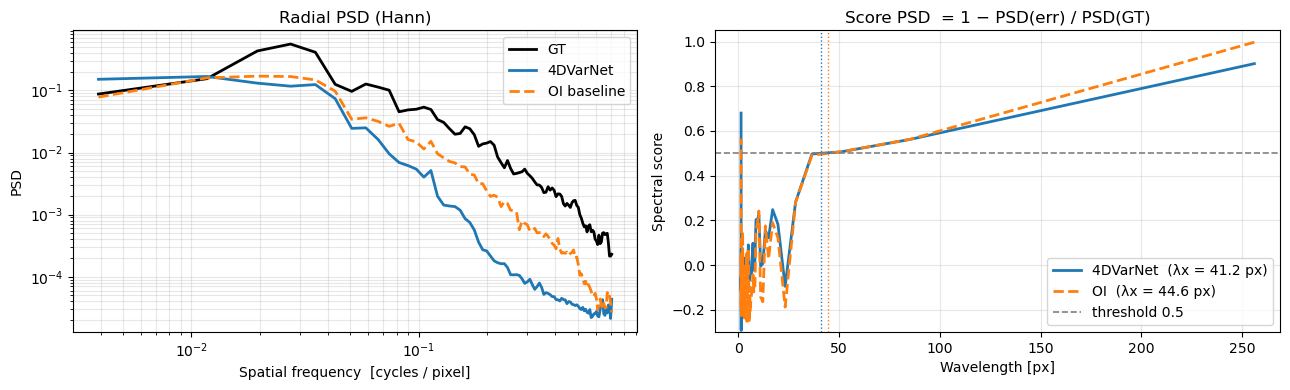

In [19]:
import sys
sys.path.append('../..')   # -> consistency/
from spectral_utils import radial_psd_2d, psd_spectral_score, resolved_scale
import pandas as pd

T_EVAL = datamodule.window_size // 2   # centre of assimilation window
DX_PX  = 1.0                           # 1 pixel = 1 km (assumption)

# Fields at time T_EVAL — denormalise to physical units
gt_n    = x_true[_b, T_EVAL].float().cpu().numpy()   # (H, W) normalized
gt_p    = gt_n   * s_norm + m_norm

pred_n  = x_hat[_b, T_EVAL].float().cpu().numpy()    # (H, W) normalized
pred_p  = pred_n * s_norm + m_norm

oi_p    = datamodule.oi[start_t + T_EVAL].astype(np.float32)   # (H, W) physical

sigma_gt = float(np.nanstd(gt_p))
print(f't={T_EVAL} | sigma(GT)={sigma_gt:.4f}')

def _metrics_row(pred_p, gt_p, label, dx=DX_PX):
    sigma      = float(np.nanstd(gt_p))
    rmse_v     = float(np.sqrt(np.nanmean((pred_p - gt_p) ** 2)))
    score      = 1.0 - rmse_v / sigma
    sigma_pred = float(np.nanstd(pred_p))
    wl, _, _, spec = psd_spectral_score(pred_p, gt_p, dx=dx)
    lambda_x   = resolved_scale(wl, spec, threshold=0.5)
    return {
        'Method'   : label,
        'Score ↑'  : f'{score:.3f}',
        'RMSE ↓'   : f'{rmse_v:.4f}',
        'σ_GT'     : f'{sigma:.4f}',
        'σ_pred'   : f'{sigma_pred:.4f}',
        'λx [px]'  : f'{lambda_x:.1f}' if not np.isnan(lambda_x) else '?',
    }, wl, spec

row_4dv, wl_4dv, spec_4dv = _metrics_row(pred_p, gt_p, '4DVarNet')
row_oi,  wl_oi,  spec_oi  = _metrics_row(oi_p,   gt_p, 'OI baseline')

df_metrics = pd.DataFrame([row_4dv, row_oi]).set_index('Method')
df_metrics.columns = ['Score ↑','RMSE ↓','σ_GT','σ_pred','λx [px]']
print(f'\n## Metrics @ t={T_EVAL} -- 1 pixel = {DX_PX:.0f} km\n')
display(df_metrics)

# ── Signal PSDs (radial, Hann-windowed) ───────────────────────────────────────
wl_gt,   psd_gt_sig   = radial_psd_2d(gt_p,   dx=DX_PX)
wl_4dv2, psd_4dv_sig  = radial_psd_2d(pred_p, dx=DX_PX)
wl_oi2,  psd_oi_sig   = radial_psd_2d(oi_p,   dx=DX_PX)

lambda_x_4dv = resolved_scale(wl_4dv, spec_4dv)
lambda_x_oi  = resolved_scale(wl_oi,  spec_oi)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for wl, psd, color, ls, lbl in [
    (wl_gt,   psd_gt_sig,   'black', '-',  'GT'),
    (wl_4dv2, psd_4dv_sig,  'C0',   '-',  '4DVarNet'),
    (wl_oi2,  psd_oi_sig,   'C1',   '--', 'OI baseline'),
]:
    v = np.isfinite(wl) & np.isfinite(psd) & (wl > 0) & (psd > 0)
    ax.loglog(1.0/wl[v], psd[v], color=color, ls=ls, lw=2, label=lbl)
ax.set_xlabel('Spatial frequency  [cycles / pixel]')
ax.set_ylabel('PSD')
ax.set_title('Radial PSD (Hann)')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
lbl_4dv = f'4DVarNet  (λx = {lambda_x_4dv:.1f} px)' if not np.isnan(lambda_x_4dv) else '4DVarNet'
lbl_oi  = f'OI  (λx = {lambda_x_oi:.1f} px)'         if not np.isnan(lambda_x_oi)  else 'OI'
for wl, spec, color, ls, lbl in [
    (wl_4dv, spec_4dv, 'C0', '-',  lbl_4dv),
    (wl_oi,  spec_oi,  'C1', '--', lbl_oi),
]:
    v = np.isfinite(wl) & np.isfinite(spec)
    ax.plot(wl[v], spec[v], color=color, ls=ls, lw=2, label=lbl)
ax.axhline(0.5, color='gray', lw=1.2, ls='--', label='threshold 0.5')
if not np.isnan(lambda_x_4dv):
    ax.axvline(lambda_x_4dv, color='C0', lw=1, ls=':')
if not np.isnan(lambda_x_oi):
    ax.axvline(lambda_x_oi,  color='C1', lw=1, ls=':')
ax.set_xlabel('Wavelength [px]')
ax.set_ylabel('Spectral score')
ax.set_title('Score PSD  = 1 − PSD(err) / PSD(GT)')
ax.set_ylim(-0.3, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Publication Figures


  Saved: figures/4DVarNet_spde/4DVarNet_spde_obs.png


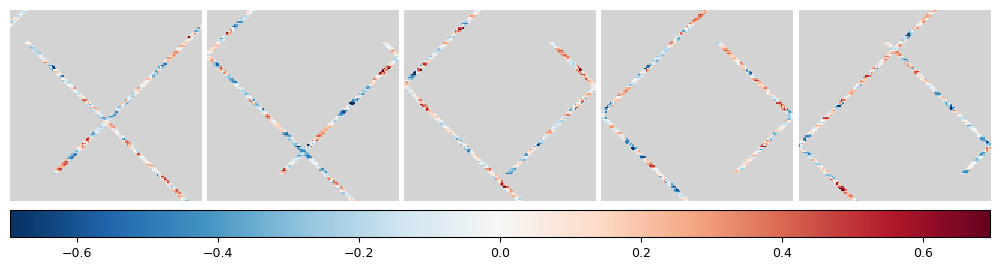

  Saved: figures/4DVarNet_spde/4DVarNet_spde_gt.png


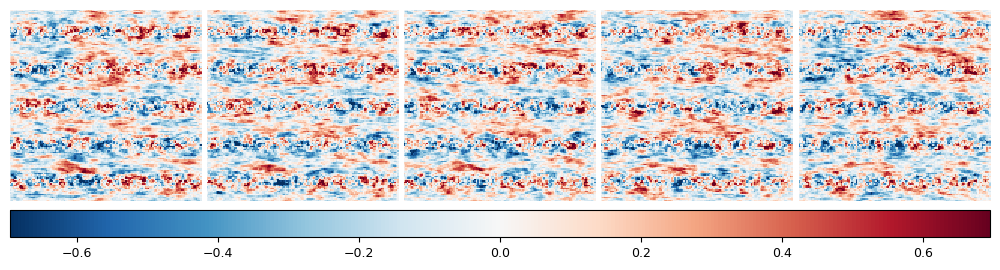

  Saved: figures/4DVarNet_spde/4DVarNet_spde_oi.png


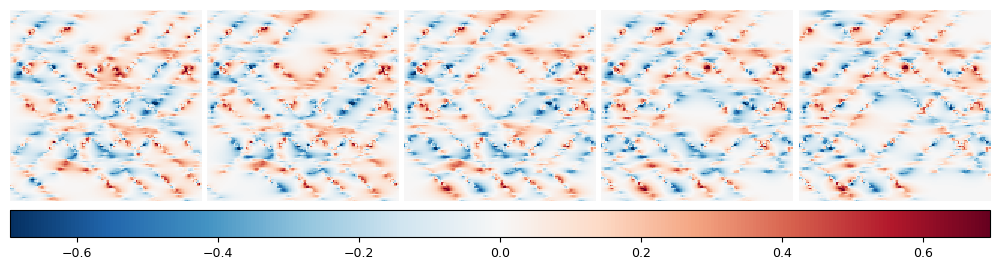

  Saved: figures/4DVarNet_spde/4DVarNet_spde_pred.png


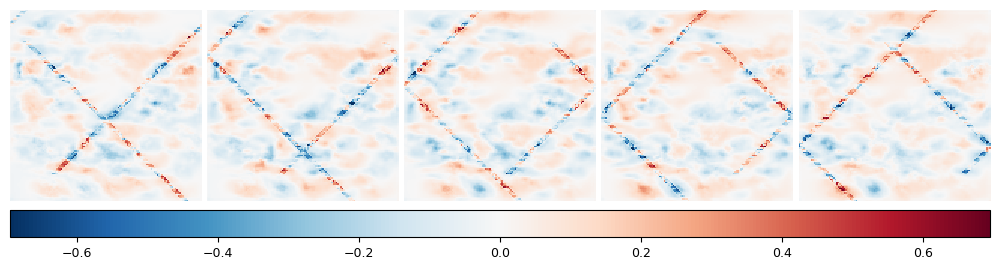

In [24]:
from matplotlib.gridspec import GridSpec

FIG_TAG = '4DVarNet_spde'
FIG_DIR = os.path.join('figures', FIG_TAG)
os.makedirs(FIG_DIR, exist_ok=True)

C = datamodule.window_size
ws = C

obs_phys  = batch.input[_b].float().cpu().numpy() * s_norm + m_norm   # (C,H,W)
gt_phys   = batch.tgt[_b].float().cpu().numpy()   * s_norm + m_norm   # (C,H,W)
oi_phys   = datamodule.oi[start_t: start_t + ws].astype(np.float32)
pred_phys = x_hat[_b].float().cpu().numpy()       * s_norm + m_norm   # (C,H,W)

vmax_f = float(np.nanpercentile(np.abs(gt_phys), 99))
vmin_f = -vmax_f

cmap_f = plt.cm.RdBu_r.copy(); cmap_f.set_bad('lightgray')

def _save_strip(data, filename, vmin, vmax, cmap):
    FW, FH, CB_H = 2.0, 2.0, 0.28
    fig_w = C * FW
    fig_h = FH + CB_H + 0.06
    fig = plt.figure(figsize=(fig_w, fig_h))
    gs = GridSpec(2, C,
                  left=0.01, right=0.99, top=0.99, bottom=0.01,
                  height_ratios=[FH, CB_H], hspace=0.06, wspace=0.03)
    for c in range(C):
        ax = fig.add_subplot(gs[0, c])
        ax.imshow(data[c], origin='lower', cmap=cmap,
                  vmin=vmin, vmax=vmax, interpolation='nearest')
        ax.axis('off')
    ax_cb = fig.add_subplot(gs[1, :])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cb = fig.colorbar(sm, cax=ax_cb, orientation='horizontal')
    cb.ax.tick_params(labelsize=9)
    fpath = os.path.join(FIG_DIR, f'{filename}.png')
    fig.savefig(fpath, dpi=200, bbox_inches='tight')
    print(f'  Saved: {fpath}')
    plt.show()

figures = [
    (obs_phys,  f'{FIG_TAG}_obs',  vmin_f, vmax_f, cmap_f),
    (gt_phys,   f'{FIG_TAG}_gt',   vmin_f, vmax_f, cmap_f),
    (oi_phys,   f'{FIG_TAG}_oi',   vmin_f, vmax_f, cmap_f),
    (pred_phys, f'{FIG_TAG}_pred', vmin_f, vmax_f, cmap_f),
]

for data, fname, vmin, vmax, cmap in figures:
    _save_strip(data, fname, vmin, vmax, cmap)


In [ ]:
# --- metrics serialization (patch_notebook_params.py) ---
import os
os.makedirs(os.path.dirname(METRICS_CSV) or '.', exist_ok=True)
_df_out = df_metrics.reset_index() if df_metrics.index.name == 'Method' else df_metrics
_df_out.to_csv(METRICS_CSV, index=False)
print(f'Metrics written to {METRICS_CSV}')
